Контрольне питання 4.

Якщо значення X знаходиться всередині спостереженого діапазону, прогноз є інтерполяцією. Якщо воно виходить за межі діапазону, це екстраполяція. Для екстраполяції надійність прогнозу зазвичай нижча, оскільки модель не перевірялася на спостереженнях у цій області.


Контрольне питання 3.

Високе R² не гарантує адекватності лінійної моделі. Графік залишків може показати вигнуту структуру, систематичні зміни розкиду, викиди або інші закономірності, які одне число R² не відображає. Тому залишки потрібно перевіряти разом із числовими показниками моделі.


Контрольне питання 2.

Коефіцієнт b1 має одиниці вимірювання тис. грн на 1°C і показує середню зміну витрат при збільшенні температури на 1°C. Коефіцієнт кореляції r не має одиниць вимірювання та показує силу й напрямок лінійного зв'язку. Отже, b1 має безпосередню змістовну одиницю зміни витрат, а r є стандартизованою мірою сили зв'язку.


Контрольне питання 1.

Метод найменших квадратів мінімізує суму квадратів залишків, оскільки квадрати роблять усі відхилення невід'ємними та сильніше враховують великі помилки. Сума самих залишків може дорівнювати нулю через взаємне компенсування додатних і від'ємних відхилень. Квадрати також дають зручну математичну задачу з однозначним розв'язком для простої лінійної регресії.


Завдання 5.

p-value з linregress() і p-value з pearsonr() для цієї простої лінійної регресії збігаються або є практично однаковими. Це пов'язано з тим, що для простої регресії з одним предиктором перевірка H0: b1 = 0 еквівалентна перевірці H0: ρ = 0. Нульовий нахил означає відсутність лінійного зв'язку між X та Y, що відповідає нульовій популяційній кореляції за стандартних припущень тесту.


Завдання 4.

Температура -10°C виходить за межі фактичного діапазону температур мого набору. Тому прогноз для -10°C є екстраполяцією. Надійність такого прогнозу нижча, оскільки лінійна модель була оцінена лише на спостережуваному діапазоні температур і її поведінка за межами цього діапазону безпосередньо даними не перевірена.


Завдання 3.

Залишки показують різницю між фактичними та передбаченими моделлю витратами. На графіку слід оцінити, чи розташовані вони приблизно навколо нульової лінії без систематичної форми.

У цьому наборі витрати додатково обмежуються знизу нулем через max(cost, 0). Через це для найтепліших місяців можуть виникати систематичні залишки, оскільки лінійна модель може формально передбачати дуже низькі або навіть від'ємні витрати, тоді як фактичні значення не можуть бути меншими за нуль. Тому навіть відносно високе R² саме по собі не гарантує повної адекватності лінійної моделі.


Завдання 2.

R², обчислений через result.rvalue², збігається з R², отриманим за формулою
1 - SS_залишків / SS_загальна.

Для простої лінійної регресії R² = r², де r — коефіцієнт кореляції Пірсона. Отже, температура пояснює отриману частку варіації витрат на опалення, а решта варіації пов'язана з іншими факторами та випадковим шумом генерації даних.


Завдання 1.

Отримане рівняння лінійної регресії має вигляд:
витрати ≈ b0 + b1 × температура.

Коефіцієнт b1 показує, на скільки тис. грн у середньому змінюються витрати на опалення при зміні середньомісячної температури на 1°C. Від'ємний знак нахилу є логічним: зі зростанням температури потреба в опаленні та відповідні витрати зазвичай зменшуються.


In [12]:
print("===== ПІДСУМОК =====")
print(f"Місто: {city}")
print(f"Рівняння: витрати ≈ {b0:.3f} + ({b1:.3f}) × температура")
print(f"R² = {r2_linregress:.3f}")
print(f"p-value регресії = {result.pvalue:.6f}")
print(f"r Пірсона = {r:.3f}")
print(f"r² = {r**2:.3f}")
print(f"95% діапазон X: від {temp_min} до {temp_max} °C")
print(f"Прогноз при -10°C = {forecast:.3f} тис. грн")

===== ПІДСУМОК =====
Місто: Київ
Рівняння: витрати ≈ 2.317 + (-0.124) × температура
R² = 0.650
p-value регресії = 0.001528
r Пірсона = -0.806
r² = 0.650
95% діапазон X: від -4 до 21 °C
Прогноз при -10°C = 3.556 тис. грн


In [11]:
print(f"p-value linregress = {result.pvalue:.10f}")
print(f"p-value pearsonr   = {pearson_result.pvalue:.10f}")
print(f"Різниця             = {abs(result.pvalue - pearson_result.pvalue):.10e}")

p-value linregress = 0.0015284549
p-value pearsonr   = 0.0015284549
Різниця             = 1.7564075194e-17


In [10]:
temperature_new = -10

forecast = b0 + b1 * temperature_new

temp_min = x.min()
temp_max = x.max()

print(f"Мінімальна температура у вибірці: {temp_min} °C")
print(f"Максимальна температура у вибірці: {temp_max} °C")
print(f"Температура для прогнозу: {temperature_new} °C")
print(f"Прогнозовані витрати: {forecast:.3f} тис. грн")

if temp_min <= temperature_new <= temp_max:
    print("Це прогноз у межах спостереженого діапазону.")
else:
    print("Це екстраполяція за межі спостереженого діапазону.")

Мінімальна температура у вибірці: -4 °C
Максимальна температура у вибірці: 21 °C
Температура для прогнозу: -10 °C
Прогнозовані витрати: 3.556 тис. грн
Це екстраполяція за межі спостереженого діапазону.


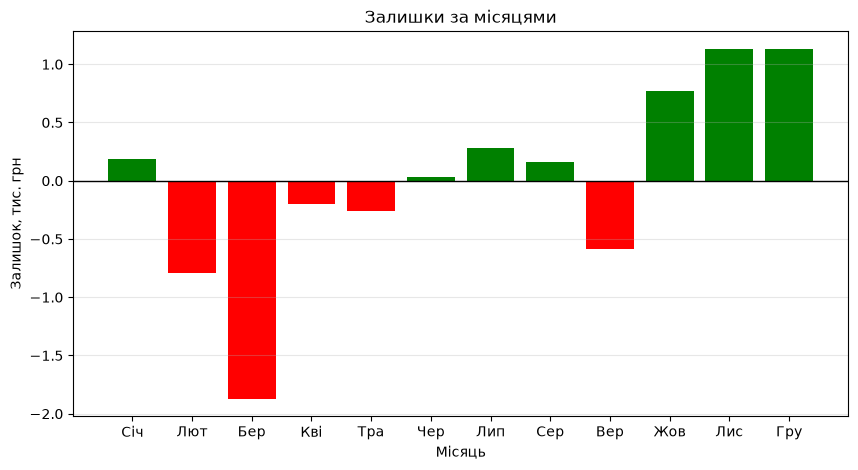

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    climate["місяць"],
    climate["залишок"],
    color=["green" if r >= 0 else "red"
           for r in climate["залишок"]]
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Місяць")
plt.ylabel("Залишок, тис. грн")
plt.title("Залишки за місяцями")
plt.grid(axis="y", alpha=0.3)
plt.show()

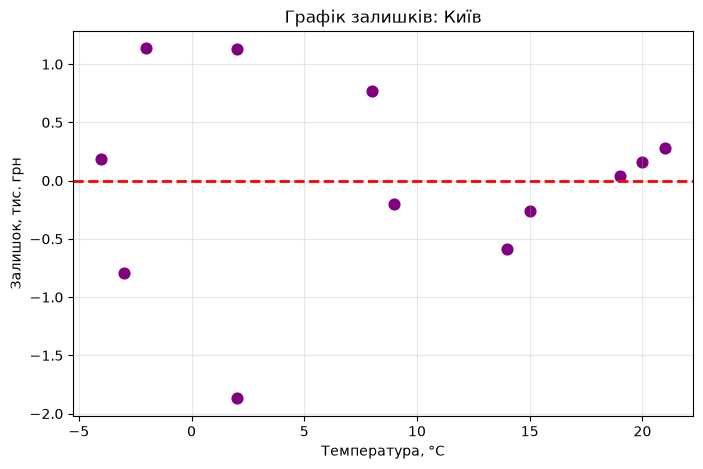

In [8]:
plt.figure(figsize=(8, 5))

plt.scatter(
    climate["температура"],
    climate["залишок"],
    color="purple",
    s=60
)

plt.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Температура, °C")
plt.ylabel("Залишок, тис. грн")
plt.title(f"Графік залишків: {city}")
plt.grid(alpha=0.3)
plt.show()

In [7]:
residuals = y - predicted

climate["передбачені_витрати"] = predicted
climate["залишок"] = residuals

climate[[
    "місяць",
    "температура",
    "витрати_на_опалення",
    "передбачені_витрати",
    "залишок"
]]

,місяць,температура,витрати_на_опалення,передбачені_витрати,залишок
0,Січ,-4,3.0,2.812916,0.187084
1,Лют,-3,1.9,2.689057,-0.789057
2,Бер,2,0.2,2.069762,-1.869762
3,Кві,9,1.0,1.202749,-0.202749
4,Тра,15,0.2,0.459595,-0.259595
5,Чер,19,0.0,-0.035841,0.035841
6,Лип,21,0.0,-0.283559,0.283559
7,Сер,20,0.0,-0.159700,0.159700
8,Вер,14,0.0,0.583454,-0.583454
9,Жов,8,2.1,1.326608,0.773392


In [6]:
pearson_result = pearsonr(x, y)

r = pearson_result.statistic
r2_from_pearson = r ** 2

print(f"Коефіцієнт Пірсона r = {r:.6f}")
print(f"r² = {r2_from_pearson:.6f}")
print(f"R² регресії = {r2_linregress:.6f}")

Коефіцієнт Пірсона r = -0.806495
r² = 0.650435
R² регресії = 0.650435


In [5]:
y_mean = y.mean()

ss_total = np.sum((y - y_mean) ** 2)
ss_residual = np.sum((y - predicted) ** 2)

r2_formula = 1 - ss_residual / ss_total
r2_linregress = result.rvalue ** 2

print(f"R² через rvalue² = {r2_linregress:.6f}")
print(f"R² через 1 - SS_res/SS_total = {r2_formula:.6f}")
print(f"Різниця = {abs(r2_linregress - r2_formula):.10f}")

print(f"\nЧастка поясненої варіації: {r2_formula * 100:.2f}%")
print(f"Частка непоясненої варіації: {(1-r2_formula) * 100:.2f}%")

R² через rvalue² = 0.650435
R² через 1 - SS_res/SS_total = 0.650435
Різниця = 0.0000000000

Частка поясненої варіації: 65.04%
Частка непоясненої варіації: 34.96%


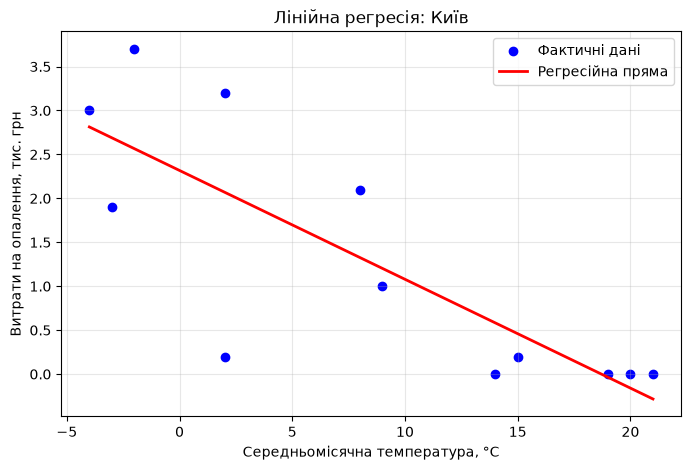

In [4]:
predicted = result.intercept + result.slope * x

plt.figure(figsize=(8, 5))

plt.scatter(x, y, color="blue", label="Фактичні дані")

order = np.argsort(x)
plt.plot(
    x[order],
    predicted[order],
    color="red",
    linewidth=2,
    label="Регресійна пряма"
)

plt.xlabel("Середньомісячна температура, °C")
plt.ylabel("Витрати на опалення, тис. грн")
plt.title(f"Лінійна регресія: {city}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [3]:
x = climate["температура"].to_numpy()
y = climate["витрати_на_опалення"].to_numpy()

result = linregress(x, y)

b1 = result.slope
b0 = result.intercept

print(f"Нахил b1 = {b1:.3f}")
print(f"Перетин b0 = {b0:.3f}")
print(f"R² = {result.rvalue**2:.3f}")
print(f"p-value = {result.pvalue:.6f}")

print(f"\nРівняння регресії:")
print(f"витрати ≈ {b0:.3f} + ({b1:.3f}) × температура")

Нахил b1 = -0.124
Перетин b0 = 2.317
R² = 0.650
p-value = 0.001528

Рівняння регресії:
витрати ≈ 2.317 + (-0.124) × температура


In [2]:
np.random.seed(1)

city = "Київ"
monthly_temp = [-4, -3, 2, 9, 15, 19, 21, 20, 14, 8, 2, -2]

months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
          "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]

rows = []

for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(
        18 - temp + np.random.normal(0, 1.5), 0, 30
    )
    heating_days = round(heating_days)

    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)

    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost
    })

climate = pd.DataFrame(rows)

climate

,місто,місяць,температура,опалювальні_дні,витрати_на_опалення
0,Київ,Січ,-4,24,3.0
1,Київ,Лют,-3,20,1.9
2,Київ,Бер,2,17,0.2
3,Київ,Кві,9,12,1.0
4,Київ,Тра,15,3,0.2
5,Київ,Чер,19,1,0.0
6,Київ,Лип,21,0,0.0
7,Київ,Сер,20,0,0.0
8,Київ,Вер,14,4,0.0
9,Київ,Жов,8,10,2.1


In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress, pearsonr
